## Composite veg health code

- Suggestion: Group 10 day time chunks into bins of pre-onset (-60>-30 days), onset (-30>0 days), early wet season (0>30 days), wet season (30 days> end of season). Could then pick timesteps within those bins where a threshold % of grids had FAPAR below a threshold to create a set of extreme composite that could be significance tested. Could look at concurrent precipitation or precipitation lagged by one timestep or 10 days.

- WHY: The previous tests are concerned with seasonality and causality but this test shows impact on intra-seasonal variability more clearly



In [185]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import pandas as pd
import gc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests

import warnings
warnings.filterwarnings('ignore')

In [186]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
datac = "/Users/ellendyer/Documents/GitHub/F4R_data/"
dataf = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_fapar/"
datal = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_lai/"
datam = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_modis/"
datatr = "/Users/ellendyer/Documents/GitHub/F4R_data/tropess_regrid/"

In [187]:
fapar = xr.open_mfdataset(dataf+'fapar_*_reg_regrid.nc')
precip = xr.open_mfdataset(datac+'chirps_10day_reg_regrid.nc') 
lai = xr.open_mfdataset(datal+'lai_*_reg_regrid.nc') 
t2m = xr.open_mfdataset(datac+'era5_10day_reg_regrid.nc') 
evap = xr.open_mfdataset(datam+'modis_*_10day_reg_regrid.nc')*0.1/8.0
sif = xr.open_mfdataset(datac+'sif_10day_reg_regrid.nc') 
hdo = xr.open_mfdataset(datac+'hdo_10day_reg_regrid.nc') 
trop = xr.open_dataset(datatr+'tropess_gridded_caf_multl_2018_2024.nc') 
trop = trop.sel(level=slice(700,500)).mean('level')
    

## Region and time bin of choice for the rest of the code

In [188]:
bandname = 'Equatorial Band'
band = 'EQ'
seas = 'Sep-Nov'
T = 0
on_ce = 'onset'

bands = {'N':[5,12,10,31],'EQ':[-5,5,10,29],'S':[-15,-5,12,31]}
band_lats=bands[band][0:2]
band_lons=bands[band][2:4]

if on_ce == 'onset':
    #dates = [[2,32],[32,62],[62,92]] #EQ1
    #dates = [[187,217],[217,247],[247,277]] #EQ2
    #dates = [[65,95],[95,125],[125,155]] #N
    dates = [[230,260],[260,290],[290,320]] #S
    timing = ['Pre-Onset','Onset','Start of Season']

if on_ce == 'cess':
    #dates = [[82,112],[112,142],[142,172]] #EQ
    #dates = [[281,311],[311,341],[341,6]] #EQ
    #dates = [[237,267],[267,297],[297,327]] #N
    dates = [[51,81],[81,111],[111,141]] #S
    timing = ['Late season','Cessation','Post-cessation']

period = dates[T]
print('days of year: ',period)
print(timing[T])

days of year:  [230, 260]
Pre-Onset


### Select latitudinal band

In [189]:
fapar = fapar.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
evap = evap.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
t2m = t2m.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
precip = precip.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
lai = lai.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
sif = sif.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
trop = trop.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)
hdo = hdo.sel(lat=slice(band_lats[0],band_lats[1]),lon=slice(band_lons[0],band_lons[1]),drop=True)

### Select the time period which will be what the composite average and composite anomalies are calculated from

In [190]:
photo_shift = 0
fapar_period = fapar.sel(time=(fapar.time.dt.dayofyear.isin(np.arange(period[0]+photo_shift,period[1]+1+photo_shift))),drop=True)
sif_period = sif.sel(time=(sif.time.dt.dayofyear.isin(np.arange(period[0]+photo_shift,period[1]+1+photo_shift))),drop=True)

pr_shift = 0
precip_period = precip.sel(time=(precip.time.dt.dayofyear.isin(np.arange(period[0]+pr_shift,period[1]+1+pr_shift))),drop=True)

lai_shift = 0
lai_period = lai.sel(time=(lai.time.dt.dayofyear.isin(np.arange(period[0]+lai_shift,period[1]+1+lai_shift))),drop=True)

hdo_shift = 0
hdo_period = hdo.sel(time=(hdo.time.dt.dayofyear.isin(np.arange(period[0]+hdo_shift,period[1]+1+hdo_shift))),drop=True)

trop_shift = 0
trop_period = trop.sel(time=(trop.time.dt.dayofyear.isin(np.arange(period[0]+trop_shift,period[1]+1+trop_shift))),drop=True)

t2m_shift = 0
t2m_period = t2m.sel(time=(t2m.time.dt.dayofyear.isin(np.arange(period[0]+t2m_shift,period[1]+1+t2m_shift))),drop=True)

evap_shift = 0
evap_period = evap.sel(time=(evap.time.dt.dayofyear.isin(np.arange(period[0]+evap_shift,period[1]+1+evap_shift))),drop=True)

print(len(precip_period.time.values), 'timesteps: ', precip_period.time.values, precip_period.time.values.tolist())
#print(len(lai_period.time.values), 'timesteps: ', lai_period.time.values)

21 timesteps:  ['2018-08-20T00:00:00.000000000' '2018-08-31T00:00:00.000000000'
 '2018-09-10T00:00:00.000000000' '2019-08-20T00:00:00.000000000'
 '2019-08-31T00:00:00.000000000' '2019-09-10T00:00:00.000000000'
 '2020-08-20T00:00:00.000000000' '2020-08-31T00:00:00.000000000'
 '2020-09-10T00:00:00.000000000' '2021-08-20T00:00:00.000000000'
 '2021-08-31T00:00:00.000000000' '2021-09-10T00:00:00.000000000'
 '2022-08-20T00:00:00.000000000' '2022-08-31T00:00:00.000000000'
 '2022-09-10T00:00:00.000000000' '2023-08-20T00:00:00.000000000'
 '2023-08-31T00:00:00.000000000' '2023-09-10T00:00:00.000000000'
 '2024-08-20T00:00:00.000000000' '2024-08-31T00:00:00.000000000'
 '2024-09-10T00:00:00.000000000'] [1534723200000000000, 1535673600000000000, 1536537600000000000, 1566259200000000000, 1567209600000000000, 1568073600000000000, 1597881600000000000, 1598832000000000000, 1599696000000000000, 1629417600000000000, 1630368000000000000, 1631232000000000000, 1660953600000000000, 1661904000000000000, 166276

### Thresholds for composites

- stack lat and lon dims to work with total number of points in a 1d array in space (time still a dimension)
- select the criteria for the fraction of points above or below which a timestep would be put into a composite set
- calculate the threshold for the chosen variable
- drop all points where the variable is above the threshold from the 1d array (e.g. just keep points with precip dryer than the threshold to count)
- keep timesteps where the the number of points remaining in space is above the specified fraction of the total number of points 
- these timesteps are those for the anomalous composite

In [191]:
composite_var = sif_period
comp_var = "SIF"

#Flatten the array to get time and all space points as a 1d dimension
flat_var = composite_var.stack(space=('lat','lon')).compute()
print('* number of points: ', flat_var.sizes['space'])
print('---------')

#Criteria percent of points crossing threshold
points = 0.5

#Calculate threshold
var_thresh = flat_var.mean('time')
#var_thresh = flat_var.quantile(q=0.75,dim="time")
#var_thresh = flat_var.quantile(q=0.25,dim="time")
print('threshold value: ',var_thresh )
print('---------')

#Drop all points where variable is above a certain threshold and count remaining points
#below this threshold > get a count per timestep
pass_var_thresh = flat_var.where(flat_var<var_thresh,drop=True).count(dim='space')
print('* counts which are under minimum threshold for each timestep :', pass_var_thresh)
print('---------')

#Keep timesteps where more than a % of the total possible space points are below the threshold
#thresh = 60% of points
pass_extent_thresh = pass_var_thresh.where(pass_var_thresh>points*flat_var.sizes['space'],drop=True)
print('* timesteps where over a % of points are below threshold (#', len(pass_extent_thresh.time.values) ,') :' , pass_extent_thresh.time.values, pass_extent_thresh.time.values.tolist() )

* number of points:  3040
---------
threshold value:  <xarray.Dataset> Size: 97kB
Dimensions:  (space: 3040)
Coordinates:
  * space    (space) object 24kB MultiIndex
  * lat      (space) float64 24kB -4.875 -4.875 -4.875 ... 4.875 4.875 4.875
  * lon      (space) float64 24kB 10.12 10.38 10.62 10.88 ... 28.38 28.62 28.88
Data variables:
    SIF      (space) float64 24kB nan nan nan nan ... 1.234 1.253 1.267 1.294
---------
* counts which are under minimum threshold for each timestep : <xarray.Dataset> Size: 336B
Dimensions:  (time: 21)
Coordinates:
  * time     (time) datetime64[ns] 168B 2018-08-20 2018-08-31 ... 2024-09-10
Data variables:
    SIF      (time) int64 168B 1470 944 663 1230 1303 ... 430 366 2346 2938 1143
---------
* timesteps where over a % of points are below threshold (# 9 ) : ['2020-08-20T00:00:00.000000000' '2020-09-10T00:00:00.000000000'
 '2021-08-20T00:00:00.000000000' '2022-08-20T00:00:00.000000000'
 '2022-08-31T00:00:00.000000000' '2022-09-10T00:00:00.000000000'


### Select timesteps from all variables

- the timesteps will differ based on the shift defined for each variable above
- the timeseries of each variable is shifted by a timedelta before selecting timesteps

In [192]:
#Select points in other variables which have the same timesteps as pass_extent_thresh

time_deltas = pd.to_timedelta(pr_shift, unit="D")
precip_comp = precip_period.sel(time=pass_extent_thresh.time.values+time_deltas,method='nearest',drop=True)

time_deltas = pd.to_timedelta(lai_shift, unit="D")
lai_comp = lai_period.sel(time=pass_extent_thresh.time.values+time_deltas,method='nearest',drop=True) 

time_deltas = pd.to_timedelta(t2m_shift, unit="D")
t2m_comp = t2m_period.sel(time=pass_extent_thresh.time.values+time_deltas,method='nearest',drop=True) 

time_deltas = pd.to_timedelta(evap_shift, unit="D")
evap_comp = evap_period.sel(time=pass_extent_thresh.time.values+time_deltas,method='nearest',drop=True) 

time_deltas = pd.to_timedelta(hdo_shift, unit="D")
hdo_comp = hdo_period.sel(time=pass_extent_thresh.time.values+time_deltas,method='nearest',drop=True) 

time_deltas = pd.to_timedelta(trop_shift, unit="D")
trop_comp = trop_period.sel(time=pass_extent_thresh.time.values+time_deltas,method='nearest',drop=True) 

time_deltas = pd.to_timedelta(photo_shift, unit="D")
fapar_comp = fapar_period.sel(time=pass_extent_thresh.time.values+time_deltas,method='nearest',drop=True) 
sif_comp = sif_period.sel(time=pass_extent_thresh.time.values+time_deltas,method='nearest',drop=True) 

#Plot the difference between selected composite and overall mean
precip_diff = precip_comp.mean('time')-precip_period.mean('time')
fapar_diff = fapar_comp.mean('time')-fapar_period.mean('time')
sif_diff = sif_comp.mean('time')-sif_period.mean('time')
lai_diff = lai_comp.mean('time')-lai_period.mean('time')
hdo_diff = hdo_comp.mean('time')-hdo_period.mean('time')
trop_diff = trop_comp.mean('time')-trop_period.mean('time')
t2m_diff = t2m_comp.mean('time')-t2m_period.mean('time')
evap_diff = evap_comp.mean('time')-evap_period.mean('time')

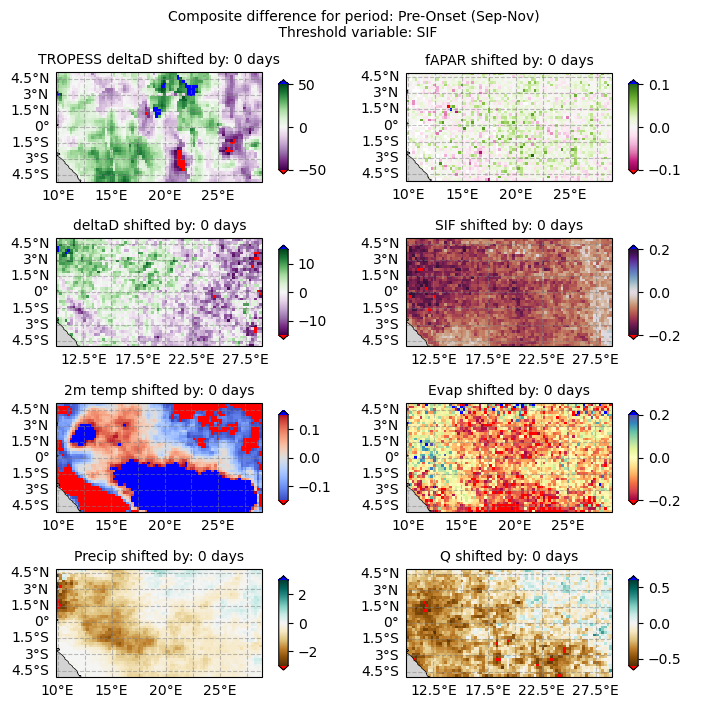

<Figure size 640x480 with 0 Axes>

In [193]:
ncols=2
nrows=4
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            
                            figsize=(7,7))
axs=axs.flatten()

#cmap=plt.cm.PuOr
#cmap.set_extremes(over='blue')
#cmap.set_extremes(under='red')
#lai_diff['LAI'].plot.pcolormesh(ax=axs[0],
#                        #vmin=-0.15, vmax=0.15,
#                        cmap=cmap,
#                        rasterized=True,
#                        add_colorbar=True,
#                        cbar_kwargs={"label": " ","orientation":"vertical",
#                                     "shrink":0.6,"extend":"both",
#                                     "fraction":0.5,"aspect":10},
#                        transform = ccrs.PlateCarree())
#axs[0].set_title('LAI shifted by: '+str(lai_shift)+' days',fontsize=10)
#axs[0].coastlines()
#axs[0].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
#gl = axs[0].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
#gl.top_labels = False
#gl.right_labels = False

cmap=plt.cm.PiYG
cmap.set_extremes(over='blue')
cmap.set_extremes(under='red')
fapar_diff['fAPAR'].plot.pcolormesh(ax=axs[1],
                        vmin=-0.1, vmax=0.1,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=True,
                        cbar_kwargs={"label": " ","orientation":"vertical",
                                     "shrink":0.6,"extend":"both",
                                     "fraction":0.5,"aspect":10},
                        transform = ccrs.PlateCarree())
axs[1].set_title('fAPAR shifted by: '+str(photo_shift)+' days',fontsize=10)
axs[1].coastlines()
axs[1].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
gl = axs[1].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cmap=plt.cm.PRGn
cmap.set_extremes(over='blue')
cmap.set_extremes(under='red')
hdo_diff['deltaD'].plot.pcolormesh(ax=axs[2],
                        vmin=-15, vmax=15,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=True,
                        cbar_kwargs={"label": " ","orientation":"vertical",
                                     "shrink":0.6,"extend":"both",
                                     "fraction":0.5,"aspect":10},
                        transform = ccrs.PlateCarree())
axs[2].set_title('deltaD shifted by: '+str(hdo_shift)+' days',fontsize=10)
axs[2].coastlines()
axs[2].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
gl = axs[2].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cmap=plt.cm.twilight_shifted_r
cmap.set_extremes(over='blue')
cmap.set_extremes(under='red')
sif_diff['SIF'].plot.pcolormesh(ax=axs[3],
                        vmin=-0.2, vmax=0.2,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=True,
                        cbar_kwargs={"label": " ","orientation":"vertical",
                                     "shrink":0.6,"extend":"both",
                                     "fraction":0.5,"aspect":10},
                        transform = ccrs.PlateCarree())
axs[3].set_title('SIF shifted by: '+str(photo_shift)+' days',fontsize=10)
axs[3].coastlines()
axs[3].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
gl = axs[3].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cmap=plt.cm.coolwarm
cmap.set_extremes(over='blue')
cmap.set_extremes(under='red')
t2m_diff['t2m'].plot.pcolormesh(ax=axs[4],
                        vmin=-0.15, vmax=0.15,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=True,
                        cbar_kwargs={"label": " ","orientation":"vertical",
                                     "shrink":0.6,"extend":"both",
                                     "fraction":0.5,"aspect":10},
                        transform = ccrs.PlateCarree())
axs[4].set_title('2m temp shifted by: '+str(t2m_shift)+' days',fontsize=10)
axs[4].coastlines()
axs[4].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
gl = axs[4].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cmap=plt.cm.Spectral
cmap.set_extremes(over='blue')
cmap.set_extremes(under='red')
evap_diff['ET_500m'].plot.pcolormesh(ax=axs[5],
                        vmin=-0.2, vmax=0.2,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=True,
                        cbar_kwargs={"label": " ","orientation":"vertical",
                                     "shrink":0.6,"extend":"both",
                                     "fraction":0.5,"aspect":10},
                        transform = ccrs.PlateCarree())
axs[5].set_title('Evap shifted by: '+str(evap_shift)+' days',fontsize=10)
axs[5].coastlines()
axs[5].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
gl = axs[5].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cmap=plt.cm.BrBG
cmap.set_extremes(over='blue')
cmap.set_extremes(under='red')
precip_diff['precip'].plot.pcolormesh(ax=axs[6],
                        vmin=-3, vmax=3,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=True,
                        cbar_kwargs={"label": " ","orientation":"vertical",
                                     "shrink":0.6,"extend":"both",
                                     "fraction":0.5,"aspect":10},
                        transform = ccrs.PlateCarree())
axs[6].set_title('Precip shifted by: '+str(pr_shift)+' days',fontsize=10)
axs[6].coastlines()
axs[6].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
gl = axs[6].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cmap=plt.cm.PRGn
cmap.set_extremes(over='blue')
cmap.set_extremes(under='red')
trop_diff['deltaD'].plot.pcolormesh(ax=axs[0],
                        vmin=-50, vmax=50,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=True,
                        cbar_kwargs={"label": " ","orientation":"vertical",
                                     "shrink":0.6,"extend":"both",
                                     "fraction":0.5,"aspect":10},
                        transform = ccrs.PlateCarree())
axs[0].set_title('TROPESS deltaD shifted by: '+str(hdo_shift)+' days',fontsize=10)
axs[0].coastlines()
axs[0].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
gl = axs[0].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cmap=plt.cm.BrBG
cmap.set_extremes(over='blue')
cmap.set_extremes(under='red')
hdo_diff['h2o_vmr'].plot.pcolormesh(ax=axs[7],
                        vmin=-0.6, vmax=0.6,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=True,
                        cbar_kwargs={"label": " ","orientation":"vertical",
                                     "shrink":0.6,"extend":"both",
                                     "fraction":0.5,"aspect":10},
                        transform = ccrs.PlateCarree())
axs[7].set_title('Q shifted by: '+str(hdo_shift)+' days',fontsize=10)
axs[7].coastlines()
axs[7].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
gl = axs[7].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False


#axs[7].remove()

plt.suptitle("Composite difference for period: "+timing[T]+" ("+seas+") \n Threshold variable: "+comp_var, fontsize=10)
plt.show()
plt.clf()
